### 1. Geometria rzutu (Pozycje na rozpiętości $y$)

Wszystkie wartości dotyczą **połowy rozpiętości** ($b/2 = 1.0\,m$).

- **`y_root` (0.05):** Szerokość kadłuba (wycięcie). Skrzydło zaczyna się 5 cm od osi symetrii.
    
- **`y_break_f` (0.3):** Pozycja profilu przejściowego. Obliczana jako 30% dystansu między kadłubem a końcówką.
    
- **`y_tip_f` (0.85):** Moment, w którym kończy się płaskie skrzydło i zaczyna wyginać się winglet (85% rozpiętości).
    

### 2. Cięciwy i Kształt (Szerokość $c$ i Skos $x$)

- **`c_root`, `c_brk`, `c_tip`:** Szerokość profilu kolejno u nasady (35 cm), w miejscu przejścia (25 cm) i na starcie wingletu (15 cm).
    
- **`x_brk` (0.1):** Skos w punkcie przejścia. Krawędź natarcia jest przesunięta o 10 cm w tył względem nasady.
    
- **`x_tip` (0.35):** Skos na końcówce. Krawędź natarcia jest 35 cm w tyle względem nasady (tworzy to strzałkę skrzydła).
    

### 3. Zwichrzenie i Wznios (Kąty $t$ i Wysokość $z$)

- **`t_root`, `t_brk`, `t_tip`:** Kąty skręcenia profilu (twist/washout). Tutaj: nasada jest zadarta o $1^{\circ}$, środek to $0^{\circ}$, a końcówka jest "odpuszczona" o $-2.5^{\circ}$ dla stabilności.
    
- **`z_brk`, `z_tip`:** Wznios (dihedral). Środek skrzydła jest 2 cm wyżej niż nasada, a końcówka 5 cm wyżej (tworzy kształt litery V).
    

### 4. Parametry Wingletu

- **`h_w` (0.15):** Całkowita wysokość wingletu (15 cm ponad płaszczyznę skrzydła). 
- **`R_w` (0.04):** Promień łuku (4 cm). Określa, jak łagodnie skrzydło przechodzi w pionowy winglet.
- **`c_w_end` (0.08):** Cięciwa na samym szczycie wingletu (zwężenie do 8 cm).
- **`sweep_w` (0.05):** Dodatkowy skos wingletu. Jego czubek jest 5 cm dalej w tyle niż jego podstawa. 
- **`toe` (1.5):** Kąt zbieżności. Winglet jest skręcony o $1.5^{\circ}$ "nosem do środka" kadłuba.
    

### 5. Wybór Profilu (Baza ID)

- **`id_root`, `id_brk`, `id_tip`, `id_w`:** Indeksy plików `.dat` w Twoim folderze. Na przykład `id_root: 3` oznacza, że u nasady zostanie użyty czwarty plik z listy (licząc od 0).

In [1]:
from solver import *
from genetic_algo import fitness_function

In [2]:
from pathlib import Path
import aerosandbox as asb
# --- PARAMETRY GLOBALNE ---
B = 1.2                 # Rozpiętość całkowita [m]
TARGET_VELOCITY = 15.0  # Prędkość przelotowa [m/s]
FIXED_MASS = 0.4        # Masa elektroniki i baterii [kg]
TOTAL_MASS = 1.0        # Docelowa masa całkowita [kg]
WING_DENSITY = 1.2      # Masa struktury skrzydła [kg/m2]
AIRFOIL_FOLDER = Path("./airfoils/") # Folder z plikami .dat

# Lista dostępnych profilów (załadowana raz na starcie)
def load_airfoils(folder):
    files = list(folder.glob("*.dat"))
    return {i: asb.Airfoil(name=f.stem, coordinates=f) for i, f in enumerate(files)}

AIRFOIL_DATABASE = load_airfoils(AIRFOIL_FOLDER)

In [3]:
asb.__version__

'4.2.9'

In [4]:
print(AIRFOIL_DATABASE)
print("Rozpiętość: ", B)
print("Prędkość przelotowa: ", TARGET_VELOCITY, "m/s")
print("Masa elektroniki i baterii: ", FIXED_MASS, "kg")
print("Gęstość struktury skrzydła: ", WING_DENSITY, "kg/m2")

{0: Airfoil AG25-il (160 points), 1: Airfoil AG35 (180 points), 2: Airfoil AG36 (180 points), 3: Airfoil AH 79-100 A (97 points), 4: Airfoil FX 60-100 (97 points), 5: Airfoil GOE 444 (33 points), 6: Airfoil NACA-0009 smoothed (69 points), 7: Airfoil RG-15 8.9% (62 points), 8: Airfoil S7012 8.75% (81 points), 9: Airfoil SD8020-010-88 (61 points)}
Rozpiętość:  1.2
Prędkość przelotowa:  15.0 m/s
Masa elektroniki i baterii:  0.4 kg
Gęstość struktury skrzydła:  1.2 kg/m2


In [5]:
test_genes ={
      "y_root": 0.0872276706540171,
        "y_break1_f": 0.5673972959466838,
        "y_break2_f": 0.3731445360774274,
        "y_tip_f": 0.8784523776400732,
        "c_root": 0.22727362169355486,
        "c_brk1": 0.101315171902162,
        "c_brk2": 0.19260734024818754,
        "c_tip": 0.16397745679782785,
        "t_root": -0.7156730432109253,
        "t_brk1": 0.9246111424643857,
        "t_brk2": 0.7781008359230102,
        "t_tip": -1.8064948046197205,
        "x_root": 0.13964042117408004,
        "x_brk1": 0.5997935368972692,
        "x_brk2": 0.7817858959304638,
        "x_tip": 0.7504014329203788,
        "z_root": 0.01805642092164675,
        "z_brk1": 0.027755074182646083,
        "z_brk2": 0.11233031789370404,
        "z_tip": 0.06793193621508689,
        "winglet_target_angle": 83.11437408377112,
        "h_w": 0.09374784000947238,
        "R_w": 0.08787118489185515,
        "c_w_end": 0.062085385286674226,
        "sweep_w": 0.009972963321320229,
        "toe": 3.5281471752305578,
        "id_root": 0.9338334551822669,
        "id_brk1": 5.5098475269547516,
        "id_tip": 4.5009912937278385,
        "id_w": 5.187557151268408
}

airplane, mass = build_airplane_curved(test_genes, 'linear')
#score, details = fitness_function(test_genes)
print(f"Samolot zbudowany pomyślnie! Szacowana masa: {mass:.3f} kg")
airplane.draw(backend='plotly')
alphas1 = np.linspace(-2, 15, 16)  # Zakres kątów natarcia
data, x_cg_target = GA_aerodynamics(airplane, TARGET_VELOCITY, alphas1)
score, score_details = fitness_function_weighted(data)
print(f"Score: {score:.2f}")
print(data)




Samolot zbudowany pomyślnie! Szacowana masa: 0.720 kg


Score: 39.60
{'ld': np.float64(22.790819343060207), 'cm_cg': np.float64(-0.0008004228147353576), 'cma': np.float64(-0.2739464807150016), 'cnb': np.float64(0.9700338672629689), 'oswald': np.float64(0.3278442568793332), 'cmq': np.float64(-31.957412415201556), 'clp': np.float64(-0.40665747071857045), 'cnr': np.float64(0.4313330271148722), 'alpha': np.float64(3.667666666666666)}


In [6]:
results = analyze_aerodynamics(airplane, mass, TARGET_VELOCITY)
print(results)


{'ld': np.float64(20.59661915879466), 'sm': 0.08, 'cnb': np.float64(0.2649313963734457), 'cl': np.float64(0.2674283570063589), 'cd': np.float64(0.012984090007420866), 'cm_cg': np.float64(0.037650461172743066), 'mass': np.float64(0.7198344337077792), 'x_np': array([0.54353732]), 'x_cg': array([0.52780281]), 'obj': AeroBuildup(
	airplane=Airplane 'Untitled' (1 wing, 0 fuselages)
	op_point=OperatingPoint instance:
	State variables:
		atmosphere: Atmosphere (altitude: 0 m (0 ft), method: 'differentiable')                                                             
		  velocity: 15.0                                                                                                                    
		     alpha: 2.0                                                                                                                     
		      beta: 1.0                                                                                                                     
		         p: 0.0          

In [7]:
metrics = calculate_extra_metrics(airplane, mass, TARGET_VELOCITY)
print(f"--- GEOMETRIA ---")
print(f"Powierzchnia: {metrics['S [m^2]']:.3f} m2")
print(f"Rozpiętość: {metrics['Span']:.3f} m")
print(f"Aerodynamic Center: {metrics['Aerodynamic center']}")
print(f"AR: {metrics['AR']:.2f} (Efektywne: {metrics['AR_eff']:.2f})")
print(f"Taper Ratio: {metrics['Taper']:.2f}")
print(f"Oswald efficiency: {metrics['e']:.3f}")
print(f"Obciążenie: {metrics['Wing Loading [kg/m^2]']:.2f} kg/m2")
print(f"Re: {metrics['Re']:.0f}")
print(f"Mean Twist Angle: {metrics['MtA']:.2f} deg")
print(f"Mean Sweep Angle: {metrics['MsA']:.2f} deg")
print(f"Mean Dihedral Angle: {metrics['MdA']:.2f} deg")

--- GEOMETRIA ---
Powierzchnia: 0.267 m2
Rozpiętość: 1.548 m
Aerodynamic Center: [0.50089863 0.         0.04441079]
AR: 9.00 (Efektywne: 10.54)
Taper Ratio: 0.16
Oswald efficiency: 0.690
Obciążenie: 2.70 kg/m2
Re: 199670
Mean Twist Angle: -0.48 deg
Mean Sweep Angle: 43.47 deg
Mean Dihedral Angle: 11.35 deg


In [8]:
'''alphas = np.linspace(-5, 12, 30)

basic_aoa = basic_analysis(
    airplane=airplane,
    velocity=18,
    alphas=alphas
)'''

'alphas = np.linspace(-5, 12, 30)\n\nbasic_aoa = basic_analysis(\n    airplane=airplane,\n    velocity=18,\n    alphas=alphas\n)'

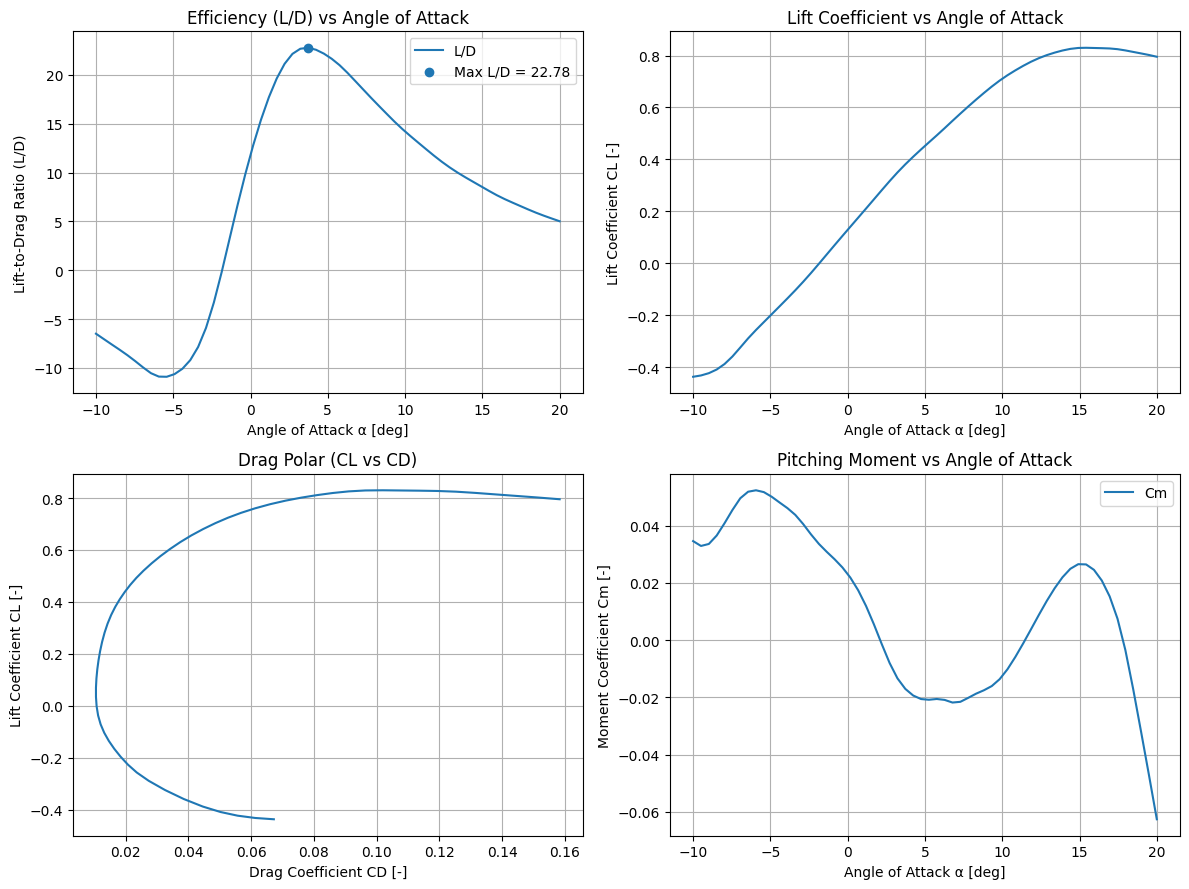


=== SUMMARY ===
Max L/D       : 22.78 at α = 3.73 deg
Oswald e      : 0.331


{'F_g': [array([-0.3516745 , -0.39339368, -0.40319992, -0.38545486, -0.35074183,
         -0.30554542, -0.25215783, -0.18928691, -0.11270762, -0.02656143,
          0.05803687,  0.13412051,  0.20068889,  0.25918549,  0.31112446,
          0.35672211,  0.39375678,  0.41816376,  0.42644122,  0.41688597,
          0.38887999,  0.34215304,  0.27665668,  0.1926984 ,  0.0912067 ,
         -0.02600836, -0.15631943, -0.29727672, -0.448044  , -0.60891337,
         -0.77972559, -0.95958041, -1.14803205, -1.34582125, -1.55156122,
         -1.76407862, -1.98280381, -2.20468779, -2.42732498, -2.65028169,
         -2.87112498, -3.08589651, -3.29184658, -3.48603151, -3.6682249 ,
         -3.84042202, -4.00449663, -4.16088823, -4.30249863, -4.41592124,
         -4.49400719, -4.5516103 , -4.60971021, -4.66414685, -4.69427613,
         -4.6898378 , -4.66376921, -4.63283708, -4.59193511, -4.52430362]),
  array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0

In [9]:
alphaSweep = analyze_alpha_sweep_and_plot(airplane, TARGET_VELOCITY, np.linspace(-10, 20, 60), metrics['Aerodynamic center'])
alphaSweep['raw_result']


In [10]:
print(alphaSweep['raw_result']['wing_aero_components'][0].oswalds_efficiency)
alphaSweep['raw_result'].keys()
#alphaSweep['raw_result']['Clb']

0.8213919735366556


dict_keys(['F_g', 'M_g', 'F_b', 'F_w', 'M_b', 'M_w', 'L', 'Y', 'D', 'l_b', 'm_b', 'n_b', 'CL', 'CY', 'CD', 'Cl', 'Cm', 'Cn', 'wing_aero_components', 'fuselage_aero_components', 'D_profile', 'D_induced', 'CLa', 'CDa', 'CYa', 'Cla', 'Cma', 'Cna', 'x_np', 'CLb', 'CDb', 'CYb', 'Clb', 'Cmb', 'Cnb', 'x_np_lateral', 'CLp', 'CDp', 'CYp', 'Clp', 'Cmp', 'Cnp', 'CLq', 'CDq', 'CYq', 'Clq', 'Cmq', 'Cnq', 'CLr', 'CDr', 'CYr', 'Clr', 'Cmr', 'Cnr'])

In [11]:
alphaSweep['raw_result']['x_np']

array([ 0.6451903 ,  0.51714956,  0.46711268,  0.45756385,  0.4649691 ,
        0.47333604,  0.48241229,  0.49373455,  0.50157697,  0.50859277,
        0.513486  ,  0.51372485,  0.51391807,  0.5180144 ,  0.52183985,
        0.52107132,  0.51749077,  0.51510398,  0.51559732,  0.5184039 ,
        0.52301984,  0.52871692,  0.53433482,  0.53844086,  0.53946408,
        0.53603372,  0.52837609,  0.51993724,  0.51300006,  0.50599236,
        0.49981151,  0.49960678,  0.50696604,  0.50483569,  0.49365601,
        0.48952576,  0.49113735,  0.49160105,  0.48561838,  0.47421005,
        0.46118205,  0.45104214,  0.44361173,  0.43458263,  0.42341218,
        0.4135104 ,  0.40898344,  0.40763905,  0.40819331,  0.42376454,
       -0.01016852, -0.13917508, -0.75464634, -0.23978711,  0.02348124,
        0.05408727,  0.01472143, -0.0121763 ,  0.02766263,  0.07546464])

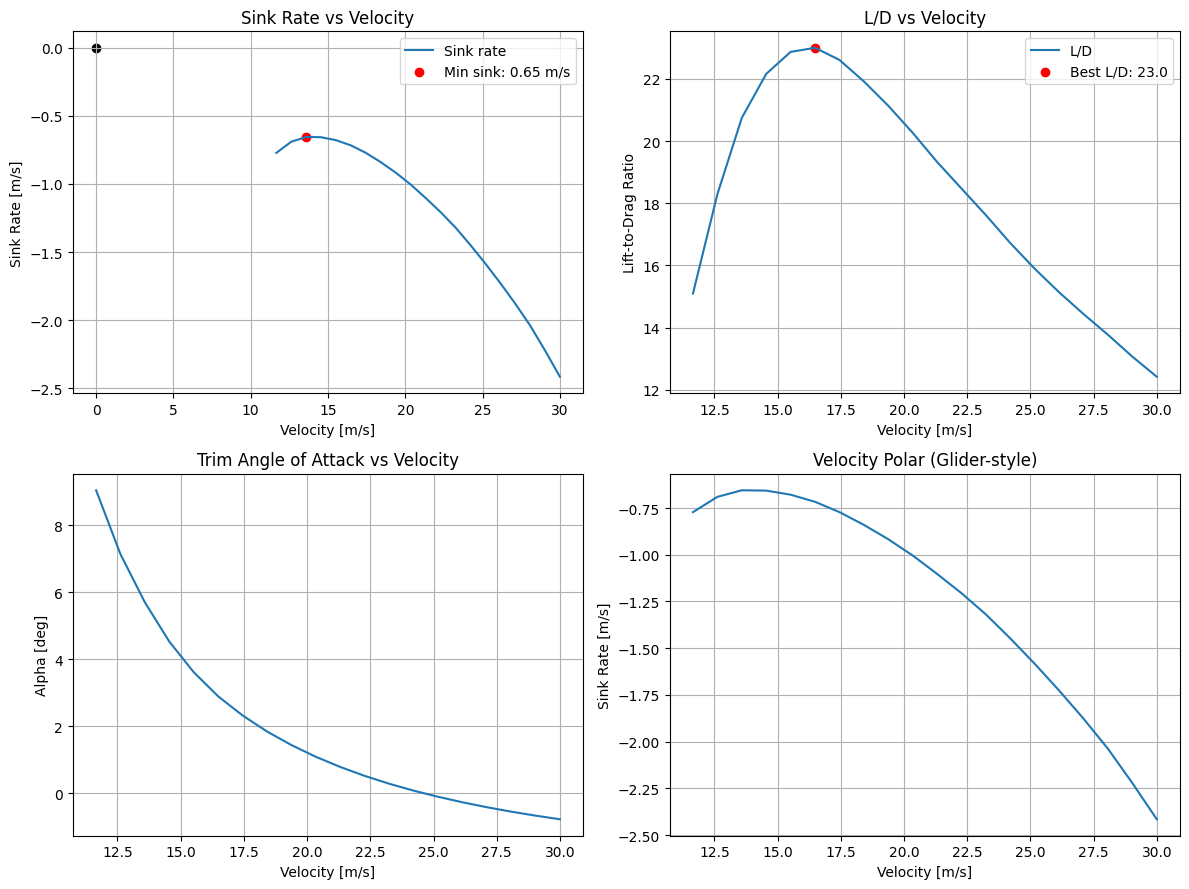


=== VELOCITY POLAR SUMMARY ===
Min sink speed   : 13.59 m/s
Min sink rate    : 0.65 m/s
Best glide speed : 16.48 m/s
Max L/D          : 23.00


In [12]:
velocities = np.linspace(2, 30, 30)

polar = analyze_velocity_polar(
    airplane=airplane,
    mass=1.5,
    velocities=velocities
)

In [13]:
op = asb.OperatingPoint(velocity=TARGET_VELOCITY, alpha=2)
ab = asb.AeroBuildup(  # This sets up the analysis, but doesn't execute calculation
    airplane=airplane,  # type: asb.Airplane
    op_point=op,  # type: asb.OperatingPoint
    xyz_ref=[results['x_cg'], 0, 0],  # Moment reference and center of rotation.
)
aero = ab.run()  # This executes the actual aero analysis.
aero_with_stability_derivs = ab.run_with_stability_derivatives() 

In [14]:
plot_wing_performance(results, airplane)

KeyError: 'vlm_obj'

Wyniki analizy:
L/D: 30.41
Static Margin: 8.00%
Cn-beta (Boczna): 0.0145
Lift Coefficient: 0.2081
Trim moment Coefficient: 0.0185
Center of Gravity: 0.1716,
Neutral Point: 0.1842

Wyniki analizy:
L/D: 27.89
Static Margin: 8.00%
Cn-beta (Boczna): 0.0501
Lift Coefficient: 0.1957
Trim moment Coefficient: 0.0251
Center of Gravity: 0.1741,
Neutral Point: 0.1864


Wyniki analizy:
L/D: 18.52
Static Margin: 8.00%
Cn-beta (Boczna): 0.1460
Lift Coefficient: 0.2068
Trim moment Coefficient: 0.0050
Center of Gravity: 0.1753,
Neutral Point: 0.1877